In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data
df = pd.read_csv("titanic.csv")

# 2. Handle missing values
# Fill missing Age with the median to avoid skewing by outliers
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with the most common port ('S')
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Drop columns with too many missing values or irrelevant data
df.drop(columns=['Cabin', 'Ticket', 'Name'], inplace=True)

# 4. Convert Survived and Pclass to categorical for better plotting
df['Survived'] = df['Survived'].map({0: 'Died', 1: 'Survived'})
df['Pclass'] = df['Pclass'].map({1: '1st Class', 2: '2nd Class', 3: '3rd Class'})

print("Titanic Data Cleaned!")
print(df)

Titanic Data Cleaned!
     PassengerId  Survived     Pclass     Sex   Age  SibSp  Parch     Fare  \
0              1      Died  3rd Class    male  22.0      1      0   7.2500   
1              2  Survived  1st Class  female  38.0      1      0  71.2833   
2              3  Survived  3rd Class  female  26.0      0      0   7.9250   
3              4  Survived  1st Class  female  35.0      1      0  53.1000   
4              5      Died  3rd Class    male  35.0      0      0   8.0500   
..           ...       ...        ...     ...   ...    ...    ...      ...   
886          887      Died  2nd Class    male  27.0      0      0  13.0000   
887          888  Survived  1st Class  female  19.0      0      0  30.0000   
888          889      Died  3rd Class  female  28.0      1      2  23.4500   
889          890  Survived  1st Class    male  26.0      0      0  30.0000   
890          891      Died  3rd Class    male  32.0      0      0   7.7500   

    Embarked  
0          S  
1          

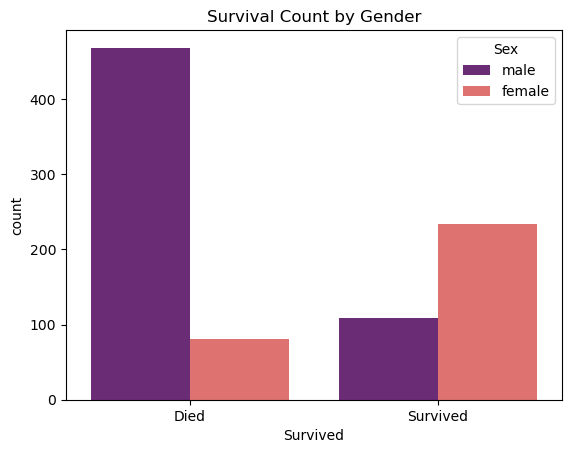

Survival Rate by Sex
Insight: There is a stark contrast in survival; females had a much higher survival rate than males.
This reflects the historical 'women and children first' evacuation policy.


In [4]:
sns.countplot(x='Survived', hue='Sex', data=df, palette='magma')
plt.title('Survival Count by Gender')
plt.show()

print("Survival Rate by Sex")
print("Insight: There is a stark contrast in survival; females had a much higher survival rate than males.\n"
      "This reflects the historical 'women and children first' evacuation policy.")

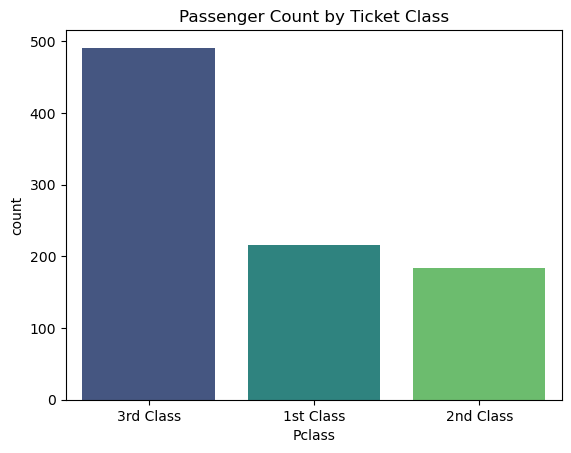

Passenger Distribution by Class
Insight: The 3rd Class was by far the largest group on the ship.
When combined with survival data, you’ll typically find that this group also faced
the highest casualty rates due to their location on the lower decks.


In [6]:
sns.countplot(x='Pclass', data=df, hue='Pclass', palette='viridis', legend=False)
plt.title('Passenger Count by Ticket Class')
plt.show()

print("Passenger Distribution by Class")
print("Insight: The 3rd Class was by far the largest group on the ship.\n" "When combined with survival data, you’ll typically find that this group also faced\n"
      "the highest casualty rates due to their location on the lower decks.")

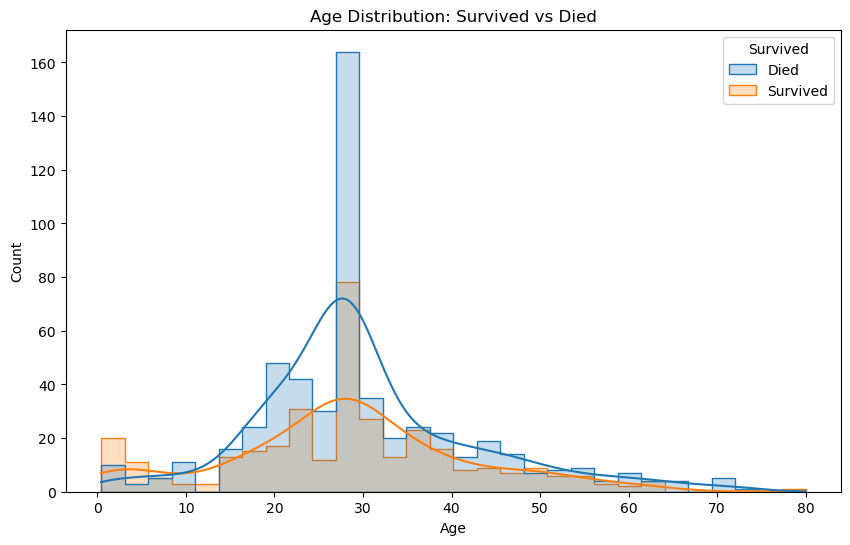

Age Distribution of Survivors vs. Deceased
Insight: The peaks in the 'Survived' distribution often appear at very young ages (children), further supporting that priority was given to the vulnerable.
There is also a significant spike in deaths for young adults (ages 18–30), who made up the bulk of the 3rd-class passengers.


In [9]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, element="step")
plt.title('Age Distribution: Survived vs Died')
plt.show()

print("Age Distribution of Survivors vs. Deceased")
print("Insight: The peaks in the 'Survived' distribution often appear at very young ages (children), further supporting that priority was given to the vulnerable.\n"
      "There is also a significant spike in deaths for young adults (ages 18–30), who made up the bulk of the 3rd-class passengers.")